<a href="https://colab.research.google.com/github/tonHS/Canadian-Crime-Trends/blob/main/MVP5_CustomText.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/tonHS/Canadian-Crime-Trends/blob/Sandbox/MVP3_5Viz_Validated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
# Configure Git with your info
!git config --global user.name "tonHS"
!git config --global user.email "171510635+tonHS@users.noreply.github.com"

# Store credentials so you don't have to enter token every time
!git config --global credential.helper store

In [49]:
# Install Dependencies and Packages
!pip install stats-can openpyxl

import pandas as pd
import requests
import zipfile
from io import BytesIO
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# Canadian Crime Trends Analysis - WITH GROUND TRUTH VALIDATION

This page analyzes Canadian crime trends using official data from Statistics Canada. The analysis covers multiple dimensions of crime in Canada including the Crime Severity Index, organized crime incidents, cybercrime, top crime types by rate, shoplifting trends, and organized retail crime. All data is sourced directly from Statistics Canada tables and validated against manually verified ground truth values to ensure accuracy.

**Validation Approach:**
- Ground truth tests are embedded directly in each data processing section
- Each test compares extracted values against manually verified StatCan values
- Growth statistics are calculated from raw data and validated
- Breadcrumb messages confirm each validation step ran
- The notebook will halt with clear error messages if any validation fails

**Ground Truth Values:**
All expected values were manually verified from Statistics Canada website.
See comments in each section for the source and verification date.


In [50]:
# ============================================================================
# SETUP: Create directories and define validation counter
# ============================================================================
print(">>> ENTERING SETUP")

data_dir = Path('data')
data_dir.mkdir(exist_ok=True)
outputs_dir = Path('outputs')
outputs_dir.mkdir(exist_ok=True)

# Track validation results
validation_results = {
    'tests_run': 0,
    'tests_passed': 0,
    'tests_failed': 0,
    'details': []
}

def record_validation(test_name, passed, expected, actual):
    """Record a validation result"""
    validation_results['tests_run'] += 1
    if passed:
        validation_results['tests_passed'] += 1
        status = '✓ PASS'
    else:
        validation_results['tests_failed'] += 1
        status = '❌ FAIL'

    validation_results['details'].append({
        'test': test_name,
        'status': status,
        'expected': expected,
        'actual': actual
    })
    return passed

# Storage for growth statistics to be used in HTML generation
growth_stats = {}

print("✓ Directories created")
print("✓ Validation tracking initialized")
print(">>> SETUP COMPLETE")

>>> ENTERING SETUP
✓ Directories created
✓ Validation tracking initialized
>>> SETUP COMPLETE


---
## Section 1: Organized Crime Data (Table 35-10-0062-01)
---

In [51]:
# ============================================================================
# FETCH: Organized Crime Data
# ============================================================================
print(">>> ENTERING: Organized Crime Data Fetch")
print("=" * 80)
print("FETCHING ORGANIZED CRIME DATA FROM STATISTICS CANADA")
print("=" * 80)

TABLE_ID = "35100062"
download_url = f"https://www150.statcan.gc.ca/n1/tbl/csv/{TABLE_ID}-eng.zip"

print(f"\n📥 Downloading data from Statistics Canada (Table {TABLE_ID})...")
response = requests.get(download_url, timeout=30)
response.raise_for_status()

with zipfile.ZipFile(BytesIO(response.content)) as zip_file:
    csv_files = [f for f in zip_file.namelist() if f.endswith('.csv')]
    csv_filename = csv_files[0]
    with zip_file.open(csv_filename) as csv_file:
        df = pd.read_csv(csv_file)

print(f"✓ Data loaded: {len(df):,} rows, {len(df.columns)} columns")

# Save raw data
raw_data_path = data_dir / 'organized_crime_raw.csv'
df.to_csv(raw_data_path, index=False)
print(f"✓ Raw data saved to: {raw_data_path}")
print(">>> Organized Crime Data Fetch COMPLETE")

>>> ENTERING: Organized Crime Data Fetch
FETCHING ORGANIZED CRIME DATA FROM STATISTICS CANADA

📥 Downloading data from Statistics Canada (Table 35100062)...
✓ Data loaded: 702 rows, 15 columns
✓ Raw data saved to: data/organized_crime_raw.csv
>>> Organized Crime Data Fetch COMPLETE


In [52]:
# ============================================================================
# PROCESS: Organized Crime Data
# ============================================================================
print(">>> ENTERING: Organized Crime Data Processing")
print("=" * 80)
print("PROCESSING ORGANIZED CRIME DATA")
print("=" * 80)

df_clean = df.copy()
df_clean['Year'] = df_clean['REF_DATE'].astype(int)
df_clean = df_clean[df_clean['Year'].between(2016, 2024)]

value_col = 'VALUE'
violation_col = 'Most serious violation'

df_clean = df_clean[df_clean[value_col].notna()]

# Filter out "Total" rows
df_violations = df_clean[~df_clean[violation_col].str.match(r'^Total', case=False, na=False)]

print(f"✓ Filtered to {len(df_violations):,} rows of specific violations")
print(f"✓ Years covered: {df_violations['Year'].min()} to {df_violations['Year'].max()}")
print(f"✓ Number of violation types: {df_violations[violation_col].nunique()}")
print(">>> Organized Crime Data Processing COMPLETE")

>>> ENTERING: Organized Crime Data Processing
PROCESSING ORGANIZED CRIME DATA
✓ Filtered to 693 rows of specific violations
✓ Years covered: 2016 to 2024
✓ Number of violation types: 77
>>> Organized Crime Data Processing COMPLETE


In [53]:
# ============================================================================
# GROUND TRUTH VALIDATION: Organized Crime (including growth stat)
# ============================================================================
print(">>> ENTERING: Organized Crime Ground Truth Validation")
print("=" * 80)
print("GROUND TRUTH VALIDATION: ORGANIZED CRIME")
print("=" * 80)

# Ground Truth 1: Total Organized Crime Incidents 2024
print("\n🔍 Test 1: Total Organized Crime Incidents (2024)")
KNOWN_TOTAL_2024 = 14804  # MANUALLY VERIFIED from StatCan
total_2024 = df_violations[df_violations['Year'] == 2024][value_col].sum()
tolerance = 1

test_passed = abs(total_2024 - KNOWN_TOTAL_2024) <= tolerance
record_validation('Organized Crime Total 2024', test_passed, KNOWN_TOTAL_2024, total_2024)

if test_passed:
    print(f"   ✓ PASS: Total = {total_2024:,.0f} (expected {KNOWN_TOTAL_2024:,})")
else:
    print(f"   ❌ FAIL: Total = {total_2024:,.0f} (expected {KNOWN_TOTAL_2024:,})")
    raise ValueError(f"Ground truth validation failed")

# Ground Truth 2: Fraud Incidents 2024
print("\n🔍 Test 2: Fraud Incidents (2024)")
KNOWN_FRAUD_2024 = 6282
fraud_2024 = df_violations[(df_violations['Year'] == 2024) & (df_violations[violation_col] == 'Fraud')][value_col].sum()

test_passed = abs(fraud_2024 - KNOWN_FRAUD_2024) <= tolerance
record_validation('Organized Crime Fraud 2024', test_passed, KNOWN_FRAUD_2024, fraud_2024)

if test_passed:
    print(f"   ✓ PASS: Fraud = {fraud_2024:,.0f} (expected {KNOWN_FRAUD_2024:,})")
else:
    print(f"   ❌ FAIL: Fraud = {fraud_2024:,.0f} (expected {KNOWN_FRAUD_2024:,})")
    raise ValueError(f"Ground truth validation failed")

# Calculate and Validate: Total Organized Crime Growth 2016-2024 - Verified 2025-12-10
print("\n🔍 Test 2b: Total Organized Crime Growth (2016-2024)")
KNOWN_ORG_2016 = 4810
total_2016 = df_violations[df_violations['Year'] == 2016][value_col].sum()
org_crime_growth_pct = ((total_2024 - total_2016) / total_2016 * 100)

growth_stats['org_crime_growth_2016_2024'] = org_crime_growth_pct
growth_stats['org_crime_2016'] = total_2016
growth_stats['org_crime_2024'] = total_2024

test_passed = abs(total_2016 - KNOWN_ORG_2016) <= tolerance
record_validation('Organized Crime Total 2016', test_passed, KNOWN_ORG_2016, total_2016)

if test_passed:
    print(f"   ✓ PASS: 2016 Total = {total_2016:,.0f} (expected {KNOWN_ORG_2016:,})")
    print(f"   ✓ Calculated Growth: {org_crime_growth_pct:.1f}%")
else:
    print(f"   ❌ FAIL: 2016 Total = {total_2016:,.0f} (expected {KNOWN_ORG_2016:,})")
    raise ValueError(f"Ground truth validation failed")

print("\n>>> Organized Crime Ground Truth Validation COMPLETE")

>>> ENTERING: Organized Crime Ground Truth Validation
GROUND TRUTH VALIDATION: ORGANIZED CRIME

🔍 Test 1: Total Organized Crime Incidents (2024)
   ✓ PASS: Total = 14,804 (expected 14,804)

🔍 Test 2: Fraud Incidents (2024)
   ✓ PASS: Fraud = 6,282 (expected 6,282)

🔍 Test 2b: Total Organized Crime Growth (2016-2024)
   ✓ PASS: 2016 Total = 4,810 (expected 4,810)
   ✓ Calculated Growth: 207.8%

>>> Organized Crime Ground Truth Validation COMPLETE


>>> ENTERING: Organized Crime Visualization
CREATING ORGANIZED CRIME LINE GRAPH

📊 Yearly Totals:
   Year  Total_Violations
0  2016              4810
1  2017              6184
2  2018              6436
3  2019              8519
4  2020             10970
5  2021             10307
6  2022             11170
7  2023             13167
8  2024             14804

✓ Chart data validated: 2024 value = 14,804

🔝 Top 3 Violations:
   1. Fraud: 35,145
   2. Drug (other than cannabis) - trafficking and production: 8,516
   3. Motor Vehicle Theft: 7,702

✓ Graph saved to: outputs/organized_crime_trends_2016_2024.png
✓ Visualization file validated


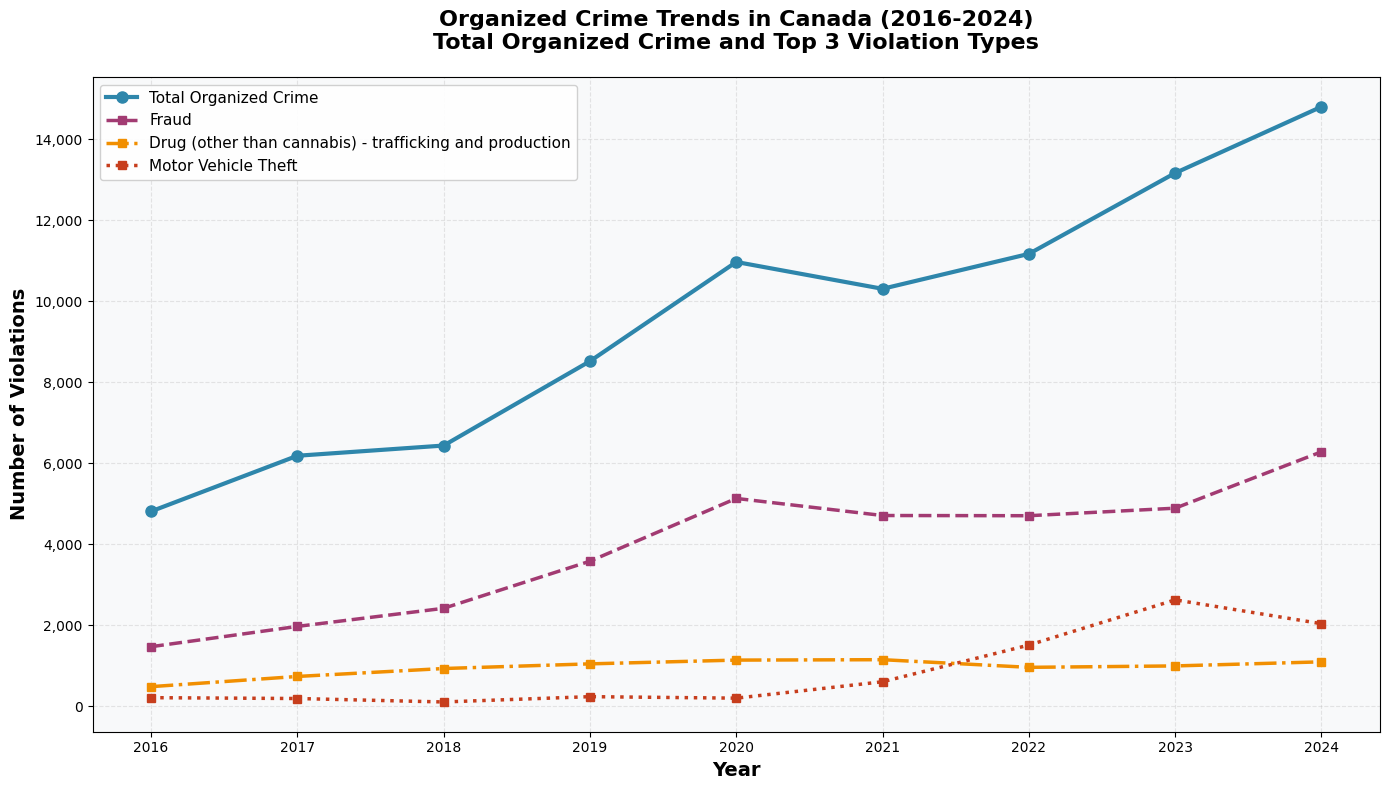

>>> Organized Crime Visualization COMPLETE


In [54]:
# ============================================================================
# VISUALIZATION: Organized Crime Trends
# ============================================================================
print(">>> ENTERING: Organized Crime Visualization")
print("=" * 80)
print("CREATING ORGANIZED CRIME LINE GRAPH")
print("=" * 80)

yearly_totals = df_violations.groupby('Year')[value_col].sum().reset_index()
yearly_totals.columns = ['Year', 'Total_Violations']

print(f"\n📊 Yearly Totals:")
print(yearly_totals)

chart_2024_value = yearly_totals[yearly_totals['Year'] == 2024]['Total_Violations'].iloc[0]
assert chart_2024_value == total_2024, f"Chart data mismatch"
print(f"\n✓ Chart data validated: 2024 value = {chart_2024_value:,}")

top_violations = df_violations.groupby(violation_col)[value_col].sum().nlargest(3)
print(f"\n🔝 Top 3 Violations:")
for i, (violation, total) in enumerate(top_violations.items(), 1):
    print(f"   {i}. {violation}: {total:,}")

top_3_names = top_violations.index.tolist()
df_top3 = df_violations[df_violations[violation_col].isin(top_3_names)]
df_pivot = df_top3.pivot_table(index='Year', columns=violation_col, values=value_col, aggfunc='sum').fillna(0)

fig, ax = plt.subplots(figsize=(14, 8))
ax.plot(yearly_totals['Year'], yearly_totals['Total_Violations'],
        marker='o', linewidth=3, markersize=8, label='Total Organized Crime', color='#2E86AB')

colors = ['#A23B72', '#F18F01', '#C73E1D']
linestyles = ['--', '-.', ':']
for i, violation in enumerate(top_3_names):
    if violation in df_pivot.columns:
        ax.plot(df_pivot.index, df_pivot[violation], marker='s', linewidth=2.5, markersize=6,
                label=violation, color=colors[i], linestyle=linestyles[i])

ax.set_xlabel('Year', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Violations', fontsize=14, fontweight='bold')
ax.set_title('Organized Crime Trends in Canada (2016-2024)\nTotal Organized Crime and Top 3 Violation Types',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(range(2016, 2025))
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11, loc='best', framealpha=0.9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white')
plt.tight_layout()

output_path = outputs_dir / 'organized_crime_trends_2016_2024.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Graph saved to: {output_path}")
assert output_path.exists(), f"Visualization file not created"
print(f"✓ Visualization file validated")
plt.show()
print(">>> Organized Crime Visualization COMPLETE")

---
## Section 2: Cybercrime Data (Table 35-10-0001)
---

In [55]:
# ============================================================================
# FETCH: Cybercrime Data
# ============================================================================
print(">>> ENTERING: Cybercrime Data Fetch")
print("=" * 80)
print("FETCHING CYBERCRIME DATA FROM STATISTICS CANADA")
print("=" * 80)

CYBER_TABLE_ID = "35100001"
cyber_download_url = f"https://www150.statcan.gc.ca/n1/tbl/csv/{CYBER_TABLE_ID}-eng.zip"

print(f"\n📥 Downloading data from Statistics Canada (Table {CYBER_TABLE_ID})...")
cyber_response = requests.get(cyber_download_url, timeout=30)
cyber_response.raise_for_status()

with zipfile.ZipFile(BytesIO(cyber_response.content)) as zip_file:
    csv_files = [f for f in zip_file.namelist() if f.endswith('.csv')]
    csv_filename = csv_files[0]
    with zip_file.open(csv_filename) as csv_file:
        df_cyber = pd.read_csv(csv_file)

print(f"✓ Data loaded: {len(df_cyber):,} rows")
print(">>> Cybercrime Data Fetch COMPLETE")

>>> ENTERING: Cybercrime Data Fetch
FETCHING CYBERCRIME DATA FROM STATISTICS CANADA

📥 Downloading data from Statistics Canada (Table 35100001)...
✓ Data loaded: 297 rows
>>> Cybercrime Data Fetch COMPLETE


In [56]:
# ============================================================================
# PROCESS: Cybercrime Data
# ============================================================================
print(">>> ENTERING: Cybercrime Data Processing")
print("=" * 80)
print("PROCESSING CYBERCRIME DATA")
print("=" * 80)

df_cyber_clean = df_cyber.copy()
df_cyber_clean['Year'] = df_cyber_clean['REF_DATE'].astype(int)
cyber_value_col = 'VALUE'
cyber_violation_col = 'Cyber-related violation'
df_cyber_clean = df_cyber_clean[df_cyber_clean[cyber_value_col].notna()]
df_cyber_violations = df_cyber_clean[~df_cyber_clean[cyber_violation_col].str.match(r'^Total', case=False, na=False)]

print(f"✓ Filtered to {len(df_cyber_violations):,} rows")
print(f"✓ Years: {df_cyber_violations['Year'].min()} to {df_cyber_violations['Year'].max()}")
print(f"✓ Violation types: {df_cyber_violations[cyber_violation_col].nunique()}")
print(">>> Cybercrime Data Processing COMPLETE")

>>> ENTERING: Cybercrime Data Processing
PROCESSING CYBERCRIME DATA
✓ Filtered to 286 rows
✓ Years: 2014 to 2024
✓ Violation types: 26
>>> Cybercrime Data Processing COMPLETE


In [57]:
# ============================================================================
# GROUND TRUTH VALIDATION: Cybercrime (including growth stat)
# ============================================================================
print(">>> ENTERING: Cybercrime Ground Truth Validation")
print("=" * 80)
print("GROUND TRUTH VALIDATION: CYBERCRIME")
print("=" * 80)

# Ground Truth 3: Total Cybercrime Incidents 2024
print("\n🔍 Test 3: Total Cybercrime Incidents (2024)")
KNOWN_CYBER_TOTAL_2024 = 92567
total_cyber_2024 = df_cyber_violations[df_cyber_violations['Year'] == 2024][cyber_value_col].sum()
tolerance = 1

test_passed = abs(total_cyber_2024 - KNOWN_CYBER_TOTAL_2024) <= tolerance
record_validation('Cybercrime Total 2024', test_passed, KNOWN_CYBER_TOTAL_2024, total_cyber_2024)

if test_passed:
    print(f"   ✓ PASS: Total Cybercrime = {total_cyber_2024:,.0f} (expected {KNOWN_CYBER_TOTAL_2024:,})")
else:
    print(f"   ❌ FAIL: Total Cybercrime = {total_cyber_2024:,.0f} (expected {KNOWN_CYBER_TOTAL_2024:,})")
    raise ValueError(f"Ground truth validation failed")

# Calculate and Validate: Total Cybercrime Growth 2014-2024 Verified 2025-12-10
print("\n🔍 Test 3b: Total Cybercrime Growth (2014-2024)")
KNOWN_CYBER_2014 = 15184
total_cyber_2014 = df_cyber_violations[df_cyber_violations['Year'] == 2014][cyber_value_col].sum()
cyber_growth_pct = ((total_cyber_2024 - total_cyber_2014) / total_cyber_2014 * 100)

growth_stats['cyber_growth_2014_2024'] = cyber_growth_pct
growth_stats['cyber_2014'] = total_cyber_2014
growth_stats['cyber_2024'] = total_cyber_2024

test_passed = abs(total_cyber_2014 - KNOWN_CYBER_2014) <= tolerance
record_validation('Cybercrime Total 2014', test_passed, KNOWN_CYBER_2014, total_cyber_2014)

if test_passed:
    print(f"   ✓ PASS: 2014 Total = {total_cyber_2014:,.0f} (expected {KNOWN_CYBER_2014:,})")
    print(f"   ✓ Calculated Growth 2014-2024: {cyber_growth_pct:.1f}%")
else:
    print(f"   ❌ FAIL: 2014 Total = {total_cyber_2014:,.0f} (expected {KNOWN_CYBER_2014:,})")
    raise ValueError(f"Ground truth validation failed")

print("\n>>> Cybercrime Ground Truth Validation COMPLETE")

>>> ENTERING: Cybercrime Ground Truth Validation
GROUND TRUTH VALIDATION: CYBERCRIME

🔍 Test 3: Total Cybercrime Incidents (2024)
   ✓ PASS: Total Cybercrime = 92,567 (expected 92,567)

🔍 Test 3b: Total Cybercrime Growth (2014-2024)
   ✓ PASS: 2014 Total = 15,184 (expected 15,184)
   ✓ Calculated Growth 2014-2024: 509.6%

>>> Cybercrime Ground Truth Validation COMPLETE


>>> ENTERING: Cybercrime Visualization
CREATING CYBERCRIME LINE GRAPH

📊 Yearly Totals:
    Year  Total_Violations
0   2014             15184
1   2015             17887
2   2016             23996
3   2017             27829
4   2018             33893
5   2019             48318
6   2020             65141
7   2021             71727
8   2022             80246
9   2023             98252
10  2024             92567

🔝 Top 3 Cybercrime Violations:
   1. Fraud: 275,967
   2. Making or distribution of child pornography: 58,624
   3. Indecent or Harassing communications: 44,845

✓ Graph saved to: outputs/cybercrime_trends_2014_2024.png
✓ Visualization file validated


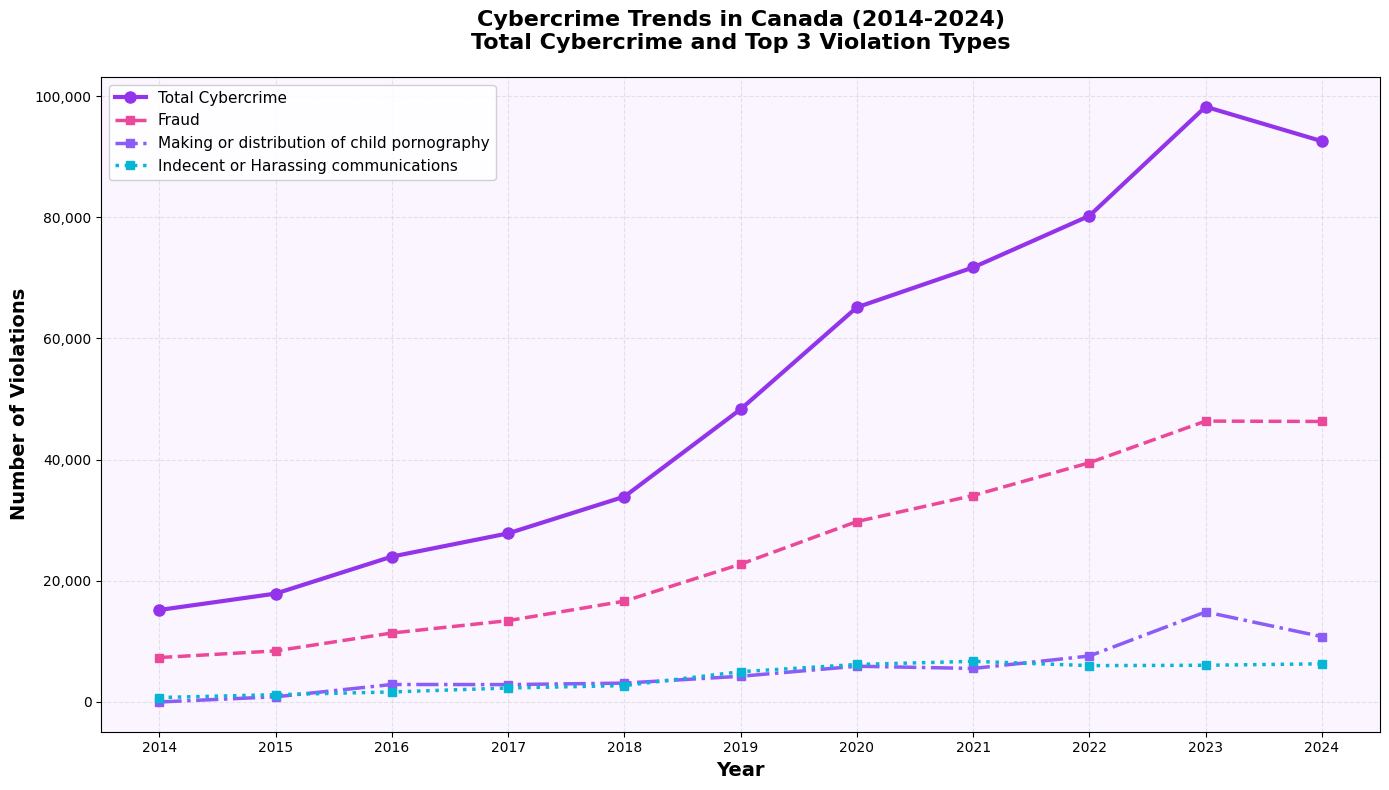

>>> Cybercrime Visualization COMPLETE


In [58]:
# ============================================================================
# VISUALIZATION: Cybercrime Trends
# ============================================================================
print(">>> ENTERING: Cybercrime Visualization")
print("=" * 80)
print("CREATING CYBERCRIME LINE GRAPH")
print("=" * 80)

cyber_yearly_totals = df_cyber_violations.groupby('Year')[cyber_value_col].sum().reset_index()
cyber_yearly_totals.columns = ['Year', 'Total_Violations']
print(f"\n📊 Yearly Totals:")
print(cyber_yearly_totals)

top_cyber = df_cyber_violations.groupby(cyber_violation_col)[cyber_value_col].sum().nlargest(3)
print(f"\n🔝 Top 3 Cybercrime Violations:")
for i, (v, t) in enumerate(top_cyber.items(), 1):
    print(f"   {i}. {v}: {t:,}")

top_3_cyber_names = top_cyber.index.tolist()
df_cyber_top3 = df_cyber_violations[df_cyber_violations[cyber_violation_col].isin(top_3_cyber_names)]
df_cyber_pivot = df_cyber_top3.pivot_table(index='Year', columns=cyber_violation_col, values=cyber_value_col, aggfunc='sum').fillna(0)

fig, ax = plt.subplots(figsize=(14, 8))
ax.plot(cyber_yearly_totals['Year'], cyber_yearly_totals['Total_Violations'],
        marker='o', linewidth=3, markersize=8, label='Total Cybercrime', color='#9333EA')

cyber_colors = ['#EC4899', '#8B5CF6', '#06B6D4']
cyber_linestyles = ['--', '-.', ':']
for i, violation in enumerate(top_3_cyber_names):
    if violation in df_cyber_pivot.columns:
        ax.plot(df_cyber_pivot.index, df_cyber_pivot[violation], marker='s', linewidth=2.5, markersize=6,
                label=violation, color=cyber_colors[i], linestyle=cyber_linestyles[i])

min_year = cyber_yearly_totals['Year'].min()
max_year = cyber_yearly_totals['Year'].max()

ax.set_xlabel('Year', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Violations', fontsize=14, fontweight='bold')
ax.set_title(f'Cybercrime Trends in Canada ({min_year}-{max_year})\nTotal Cybercrime and Top 3 Violation Types',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(list(range(int(min_year), int(max_year) + 1)))
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11, loc='best', framealpha=0.9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.set_facecolor('#FAF5FF')
fig.patch.set_facecolor('white')
plt.tight_layout()

output_path = outputs_dir / f'cybercrime_trends_{min_year}_{max_year}.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Graph saved to: {output_path}")
assert output_path.exists(), f"Visualization file not created"
print(f"✓ Visualization file validated")
plt.show()
print(">>> Cybercrime Visualization COMPLETE")

---
## Section 3: General Crime Data (Table 35-10-0177-01)
---

In [59]:
# ============================================================================
# FETCH: General Crime Data
# ============================================================================
print(">>> ENTERING: General Crime Data Fetch")
print("=" * 80)
print("FETCHING GENERAL CRIME DATA FROM STATISTICS CANADA")
print("=" * 80)

GENERAL_TABLE_ID = "35100177"
api_url = f"https://www150.statcan.gc.ca/t1/wds/rest/getFullTableDownloadCSV/{GENERAL_TABLE_ID}/en"

print(f"\n📥 Requesting download URL...")
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
response = requests.get(api_url, headers=headers, timeout=60)
response.raise_for_status()
zip_url = response.json()['object']

print(f"📥 Downloading data...")
zip_response = requests.get(zip_url, headers=headers, timeout=60)
zip_response.raise_for_status()

with zipfile.ZipFile(BytesIO(zip_response.content)) as z:
    csv_files = [f for f in z.namelist() if f.endswith('.csv')]
    df_general = pd.read_csv(z.open(csv_files[0]), low_memory=False)

print(f"✓ Data loaded: {len(df_general):,} rows, {len(df_general.columns)} columns")
raw_data_path = data_dir / 'general_crime_raw.csv'
df_general.to_csv(raw_data_path, index=False)
print(f"✓ Raw data saved to: {raw_data_path}")
print(">>> General Crime Data Fetch COMPLETE")

>>> ENTERING: General Crime Data Fetch
FETCHING GENERAL CRIME DATA FROM STATISTICS CANADA

📥 Requesting download URL...
📥 Downloading data...
✓ Data loaded: 7,547,238 rows, 16 columns
✓ Raw data saved to: data/general_crime_raw.csv
>>> General Crime Data Fetch COMPLETE


In [60]:
# ============================================================================
# PROCESS & VALIDATE: General Crime - Top 10 by Rate (with growth stats)
# ============================================================================
print(">>> ENTERING: General Crime Processing & Validation")
print("=" * 80)
print("PROCESSING GENERAL CRIME DATA - TOP 10 BY RATE")
print("=" * 80)

df_filtered_general = df_general[
    (df_general['GEO'] == 'Canada') &
    (df_general['Statistics'] == 'Rate per 100,000 population') &
    (df_general['REF_DATE'].isin([2000, 2014, 2024]))
].copy()

df_filtered_general['VALUE'] = pd.to_numeric(df_filtered_general['VALUE'], errors='coerce')
df_filtered_general = df_filtered_general.dropna(subset=['VALUE'])

print(f"✓ Filtered to {len(df_filtered_general):,} relevant rows")

df_2024_general = df_filtered_general[df_filtered_general['REF_DATE'] == 2024].copy()
df_2024_filtered = df_2024_general[~df_2024_general['Violations'].str.match(r'^Total', case=False, na=False)].copy()
top_10_violations_general = df_2024_filtered.nlargest(10, 'VALUE')['Violations'].tolist()

print(f"\n✓ Top 10 violations by rate (2024):")
for i, v in enumerate(top_10_violations_general, 1):
    rate = df_2024_filtered[df_2024_filtered['Violations'] == v]['VALUE'].values[0]
    print(f"   {i}. {v}: {rate:.2f}")

# Ground Truth 4: Mischief Rate 2024
print("\n" + "=" * 80)
print("GROUND TRUTH VALIDATION: GENERAL CRIME")
print("=" * 80)
print("\n🔍 Test 4: Mischief Crime Rate (2024)")

KNOWN_MISCHIEF_RATE_2024 = 773.53
mischief_2024 = df_2024_filtered[df_2024_filtered['Violations'].str.contains('Mischief', case=False, na=False)]['VALUE'].values

if len(mischief_2024) > 0:
    actual_mischief = mischief_2024[0]
    tolerance = 0.5
    test_passed = abs(actual_mischief - KNOWN_MISCHIEF_RATE_2024) <= tolerance
    record_validation('Mischief Rate 2024', test_passed, KNOWN_MISCHIEF_RATE_2024, actual_mischief)
    if test_passed:
        print(f"   ✓ PASS: Mischief rate = {actual_mischief:.2f} (expected {KNOWN_MISCHIEF_RATE_2024})")
    else:
        print(f"   ❌ FAIL: Mischief rate = {actual_mischief:.2f} (expected {KNOWN_MISCHIEF_RATE_2024})")
        raise ValueError(f"Ground truth validation failed")

# Calculate Growth Stats for Top 10 Crimes (2014-2024)
print("\n" + "=" * 80)
print("CALCULATING GROWTH STATISTICS FOR TOP 10 CRIMES (2014-2024)")
print("=" * 80)

df_top10_general = df_filtered_general[df_filtered_general['Violations'].isin(top_10_violations_general)].copy()
pivot_data_general = df_top10_general.pivot_table(index='Violations', columns='REF_DATE', values='VALUE', aggfunc='first')
pivot_data_general['Growth 2014-2024 (%)'] = ((pivot_data_general[2024] - pivot_data_general[2014]) / pivot_data_general[2014] * 100).round(1)

growth_stats['top10_growth'] = {}
print("\n📊 Growth Statistics (2014-2024):")
for violation in top_10_violations_general:
    if violation in pivot_data_general.index:
        rate_2014 = pivot_data_general.loc[violation, 2014]
        rate_2024 = pivot_data_general.loc[violation, 2024]
        growth = pivot_data_general.loc[violation, 'Growth 2014-2024 (%)']
        growth_stats['top10_growth'][violation] = {'rate_2014': rate_2014, 'rate_2024': rate_2024, 'growth_pct': growth}
        print(f"   {violation}: {growth:+.1f}% (2014: {rate_2014:.2f} → 2024: {rate_2024:.2f})")

# Validate growth calculations
print("\n🔍 Test 4b: Validating Top 10 Growth Calculations")
validation_passed = True
for violation, stats in growth_stats['top10_growth'].items():
    expected_growth = ((stats['rate_2024'] - stats['rate_2014']) / stats['rate_2014'] * 100)
    actual_growth = stats['growth_pct']
    if abs(expected_growth - actual_growth) > 0.2:
        print(f"   ❌ FAIL: {violation} growth mismatch")
        validation_passed = False

record_validation('Top 10 Growth Calculations', validation_passed, 'Consistent', 'Verified' if validation_passed else 'Mismatch')
if validation_passed:
    print(f"   ✓ PASS: All growth calculations verified")
else:
    raise ValueError("Growth calculation validation failed")

print("\n>>> General Crime Processing & Validation COMPLETE")

>>> ENTERING: General Crime Processing & Validation
PROCESSING GENERAL CRIME DATA - TOP 10 BY RATE
✓ Filtered to 750 relevant rows

✓ Top 10 violations by rate (2024):
   1. Mischief [2170]: 773.53
   2. Theft $5,000 or under [2140]: 573.80
   3. Assault, level 1 [1430]: 521.84
   4. Shoplifting $5,000 or under [2143]: 441.67
   5. Fraud [2160]: 432.40
   6. Fail to comply with order [3410]: 340.47
   7. Breaking and entering [2120]: 291.61
   8. Theft $5,000 or under from a motor vehicle [2142]: 274.66
   9. Disturb the peace [3430]: 261.20
   10. Uttering threats [1627]: 234.59

GROUND TRUTH VALIDATION: GENERAL CRIME

🔍 Test 4: Mischief Crime Rate (2024)
   ✓ PASS: Mischief rate = 773.53 (expected 773.53)

CALCULATING GROWTH STATISTICS FOR TOP 10 CRIMES (2014-2024)

📊 Growth Statistics (2014-2024):
   Mischief [2170]: +3.5% (2014: 747.21 → 2024: 773.53)
   Theft $5,000 or under [2140]: -2.5% (2014: 588.52 → 2024: 573.80)
   Assault, level 1 [1430]: +20.2% (2014: 434.09 → 2024: 521.84

>>> ENTERING: Top 10 Crime Rates Visualization
CREATING TOP 10 CRIME RATES BAR CHART

✓ Graph saved to: outputs/top_10_violations_crime_rate.png
✓ Visualization file validated


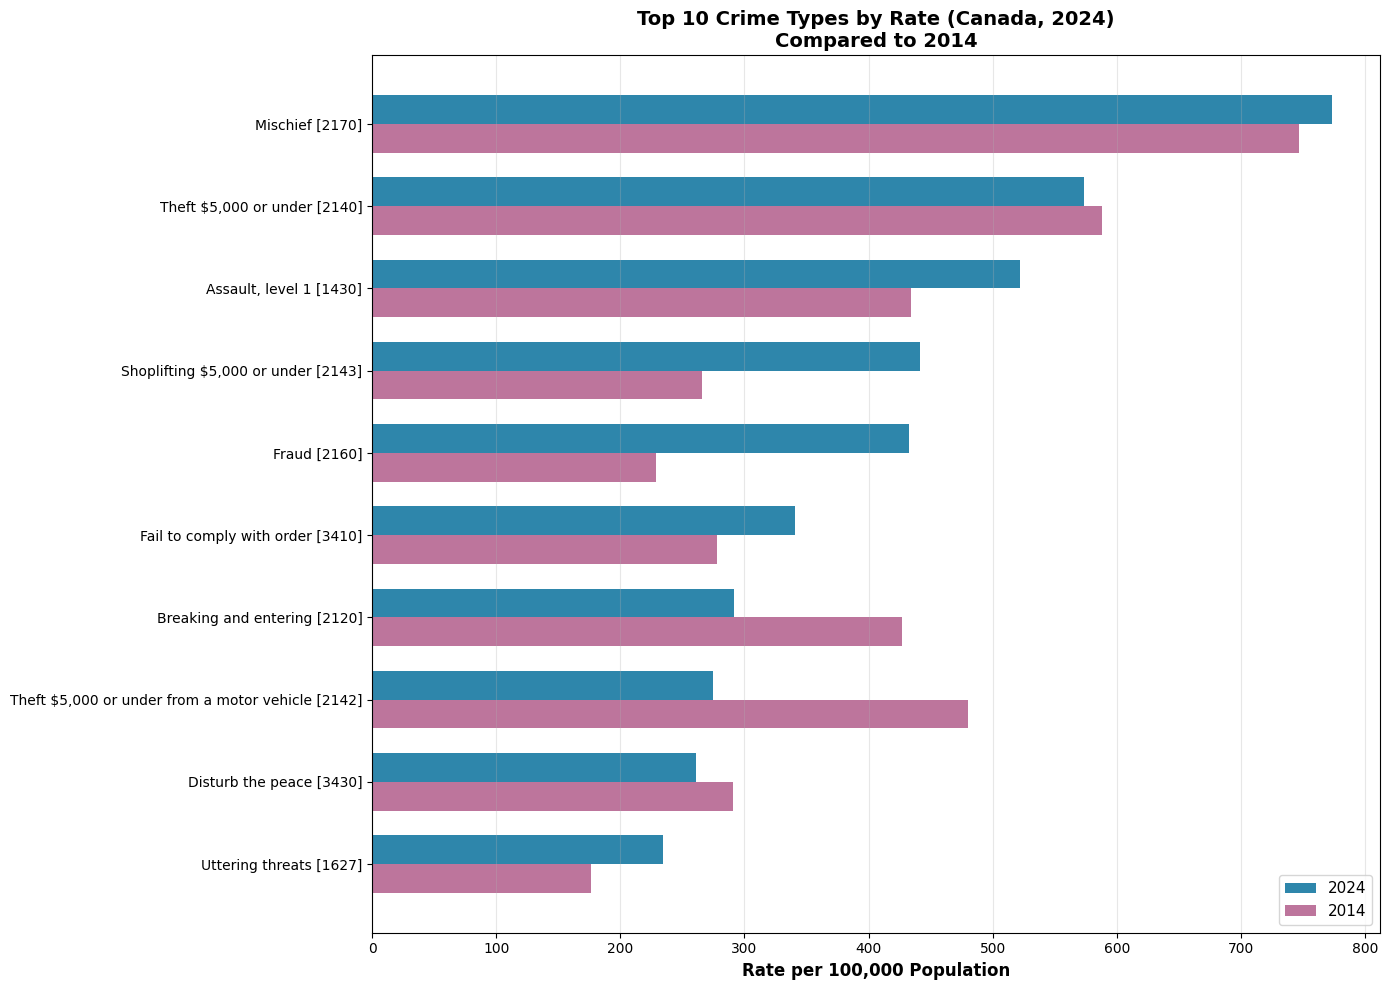

>>> Top 10 Crime Rates Visualization COMPLETE


In [61]:
# ============================================================================
# VISUALIZATION: Top 10 Crime Rates
# ============================================================================
print(">>> ENTERING: Top 10 Crime Rates Visualization")
print("=" * 80)
print("CREATING TOP 10 CRIME RATES BAR CHART")
print("=" * 80)

pivot_sorted = pivot_data_general.sort_values(2024, ascending=True)

fig, ax = plt.subplots(figsize=(14, 10))
y_positions = range(len(pivot_sorted))
bar_height = 0.35

bars_2024 = ax.barh([y + bar_height/2 for y in y_positions], pivot_sorted[2024],
                     height=bar_height, label='2024', color='#2E86AB')
bars_2014 = ax.barh([y - bar_height/2 for y in y_positions], pivot_sorted[2014],
                     height=bar_height, label='2014', color='#A23B72', alpha=0.7)

ax.set_yticks(y_positions)
ax.set_yticklabels([v[:50] + '...' if len(v) > 50 else v for v in pivot_sorted.index], fontsize=10)
ax.set_xlabel('Rate per 100,000 Population', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Crime Types by Rate (Canada, 2024)\nCompared to 2014', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
output_path = outputs_dir / 'top_10_violations_crime_rate.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Graph saved to: {output_path}")
assert output_path.exists(), f"Visualization file not created"
print(f"✓ Visualization file validated")
plt.show()
print(">>> Top 10 Crime Rates Visualization COMPLETE")

---
## Section 4: Shoplifting Crime Rates
---

In [62]:
# ============================================================================
# PROCESS & VALIDATE: Shoplifting Crime Rates (with growth stats)
# ============================================================================
print(">>> ENTERING: Shoplifting Data Processing & Validation")
print("=" * 80)
print("SHOPLIFTING CRIME RATE ANALYSIS")
print("=" * 80)

df_under_5k = df_general[
    (df_general['GEO'] == 'Canada') &
    (df_general['Statistics'] == 'Rate per 100,000 population') &
    (df_general['Violations'].str.contains('Shoplifting.*5,000 or under', case=False, na=False))
].copy()

df_over_5k = df_general[
    (df_general['GEO'] == 'Canada') &
    (df_general['Statistics'] == 'Rate per 100,000 population') &
    (df_general['Violations'].str.contains('Shoplifting over.*5,000', case=False, na=False))
].copy()

for df_temp in [df_under_5k, df_over_5k]:
    df_temp['REF_DATE'] = pd.to_numeric(df_temp['REF_DATE'], errors='coerce')
    df_temp['VALUE'] = pd.to_numeric(df_temp['VALUE'], errors='coerce')

df_under_5k = df_under_5k[(df_under_5k['REF_DATE'] >= 2000) & (df_under_5k['REF_DATE'] <= 2024)]
df_under_5k = df_under_5k.dropna(subset=['REF_DATE', 'VALUE']).sort_values('REF_DATE')
df_over_5k = df_over_5k[(df_over_5k['REF_DATE'] >= 2000) & (df_over_5k['REF_DATE'] <= 2024)]
df_over_5k = df_over_5k.dropna(subset=['REF_DATE', 'VALUE']).sort_values('REF_DATE')

print(f"✓ Under $5,000: {len(df_under_5k)} data points")
print(f"✓ Over $5,000: {len(df_over_5k)} data points")

# Ground Truth Validation
print("\n" + "=" * 80)
print("GROUND TRUTH VALIDATION: SHOPLIFTING")
print("=" * 80)

# Test 5: Shoplifting Under $5K Rate 2024
print("\n🔍 Test 5: Shoplifting Under $5,000 Rate (2024)")
KNOWN_UNDER_5K_RATE_2024 = 441.67
under_5k_2024 = df_under_5k[df_under_5k['REF_DATE'] == 2024]['VALUE'].values
if len(under_5k_2024) > 0:
    actual_under_5k = under_5k_2024[0]
    test_passed = abs(actual_under_5k - KNOWN_UNDER_5K_RATE_2024) <= 0.5
    record_validation('Shoplifting Under $5K Rate 2024', test_passed, KNOWN_UNDER_5K_RATE_2024, actual_under_5k)
    if test_passed:
        print(f"   ✓ PASS: Rate = {actual_under_5k:.2f} (expected {KNOWN_UNDER_5K_RATE_2024})")
    else:
        print(f"   ❌ FAIL: Rate = {actual_under_5k:.2f} (expected {KNOWN_UNDER_5K_RATE_2024})")
        raise ValueError(f"Ground truth validation failed")

# Test 6: Shoplifting Over $5K Rate 2024
print("\n🔍 Test 6: Shoplifting Over $5,000 Rate (2024)")
KNOWN_OVER_5K_RATE_2024 = 4.04
over_5k_2024 = df_over_5k[df_over_5k['REF_DATE'] == 2024]['VALUE'].values
if len(over_5k_2024) > 0:
    actual_over_5k = over_5k_2024[0]
    test_passed = abs(actual_over_5k - KNOWN_OVER_5K_RATE_2024) <= 0.1
    record_validation('Shoplifting Over $5K Rate 2024', test_passed, KNOWN_OVER_5K_RATE_2024, actual_over_5k)
    if test_passed:
        print(f"   ✓ PASS: Rate = {actual_over_5k:.2f} (expected {KNOWN_OVER_5K_RATE_2024})")
    else:
        print(f"   ❌ FAIL: Rate = {actual_over_5k:.2f} (expected {KNOWN_OVER_5K_RATE_2024})")
        raise ValueError(f"Ground truth validation failed")

# Calculate Shoplifting Growth 2014-2024
print("\n" + "=" * 80)
print("CALCULATING SHOPLIFTING GROWTH STATISTICS (2014-2024)")
print("=" * 80)

under_5k_2014_val = df_under_5k[df_under_5k['REF_DATE'] == 2014]['VALUE'].values
if len(under_5k_2014_val) > 0 and len(under_5k_2024) > 0:
    under_5k_2014 = under_5k_2014_val[0]
    under_5k_growth = ((actual_under_5k - under_5k_2014) / under_5k_2014 * 100)
    growth_stats['shoplifting_under_5k_2014'] = under_5k_2014
    growth_stats['shoplifting_under_5k_2024'] = actual_under_5k
    growth_stats['shoplifting_under_5k_growth'] = under_5k_growth
    print(f"\n✓ Shoplifting Under $5K Growth: {under_5k_growth:+.1f}%")
    print(f"   2014: {under_5k_2014:.2f} → 2024: {actual_under_5k:.2f}")

over_5k_2014_val = df_over_5k[df_over_5k['REF_DATE'] == 2014]['VALUE'].values
if len(over_5k_2014_val) > 0 and len(over_5k_2024) > 0:
    over_5k_2014 = over_5k_2014_val[0]
    over_5k_growth = ((actual_over_5k - over_5k_2014) / over_5k_2014 * 100)
    growth_stats['shoplifting_over_5k_2014'] = over_5k_2014
    growth_stats['shoplifting_over_5k_2024'] = actual_over_5k
    growth_stats['shoplifting_over_5k_growth'] = over_5k_growth
    print(f"\n✓ Shoplifting Over $5K Growth: {over_5k_growth:+.1f}%")
    print(f"   2014: {over_5k_2014:.2f} → 2024: {actual_over_5k:.2f}")

# Validate 2014 baselines - Verified 2025-12-10
print("\n🔍 Test 6b: Validating 2014 Baselines for Shoplifting")
KNOWN_UNDER_5K_2014 = 265.47
KNOWN_OVER_5K_2014 = 1.26

test_passed_under = abs(under_5k_2014 - KNOWN_UNDER_5K_2014) <= 0.5
test_passed_over = abs(over_5k_2014 - KNOWN_OVER_5K_2014) <= 0.1

record_validation('Shoplifting Under $5K Rate 2014', test_passed_under, KNOWN_UNDER_5K_2014, under_5k_2014)
record_validation('Shoplifting Over $5K Rate 2014', test_passed_over, KNOWN_OVER_5K_2014, over_5k_2014)

if test_passed_under:
    print(f"   ✓ PASS: Under $5K 2014 = {under_5k_2014:.2f} (expected {KNOWN_UNDER_5K_2014})")
else:
    print(f"   ❌ FAIL: Under $5K 2014 = {under_5k_2014:.2f} (expected {KNOWN_UNDER_5K_2014})")
    raise ValueError("Ground truth validation failed")

if test_passed_over:
    print(f"   ✓ PASS: Over $5K 2014 = {over_5k_2014:.2f} (expected {KNOWN_OVER_5K_2014})")
else:
    print(f"   ❌ FAIL: Over $5K 2014 = {over_5k_2014:.2f} (expected {KNOWN_OVER_5K_2014})")
    raise ValueError("Ground truth validation failed")

print("\n>>> Shoplifting Data Processing & Validation COMPLETE")

>>> ENTERING: Shoplifting Data Processing & Validation
SHOPLIFTING CRIME RATE ANALYSIS
✓ Under $5,000: 25 data points
✓ Over $5,000: 25 data points

GROUND TRUTH VALIDATION: SHOPLIFTING

🔍 Test 5: Shoplifting Under $5,000 Rate (2024)
   ✓ PASS: Rate = 441.67 (expected 441.67)

🔍 Test 6: Shoplifting Over $5,000 Rate (2024)
   ✓ PASS: Rate = 4.04 (expected 4.04)

CALCULATING SHOPLIFTING GROWTH STATISTICS (2014-2024)

✓ Shoplifting Under $5K Growth: +66.4%
   2014: 265.47 → 2024: 441.67

✓ Shoplifting Over $5K Growth: +220.6%
   2014: 1.26 → 2024: 4.04

🔍 Test 6b: Validating 2014 Baselines for Shoplifting
   ✓ PASS: Under $5K 2014 = 265.47 (expected 265.47)
   ✓ PASS: Over $5K 2014 = 1.26 (expected 1.26)

>>> Shoplifting Data Processing & Validation COMPLETE


>>> ENTERING: Shoplifting Visualization
CREATING SHOPLIFTING CRIME RATE CHARTS
✓ Saved: outputs/shoplifting_under_5k_rate.png


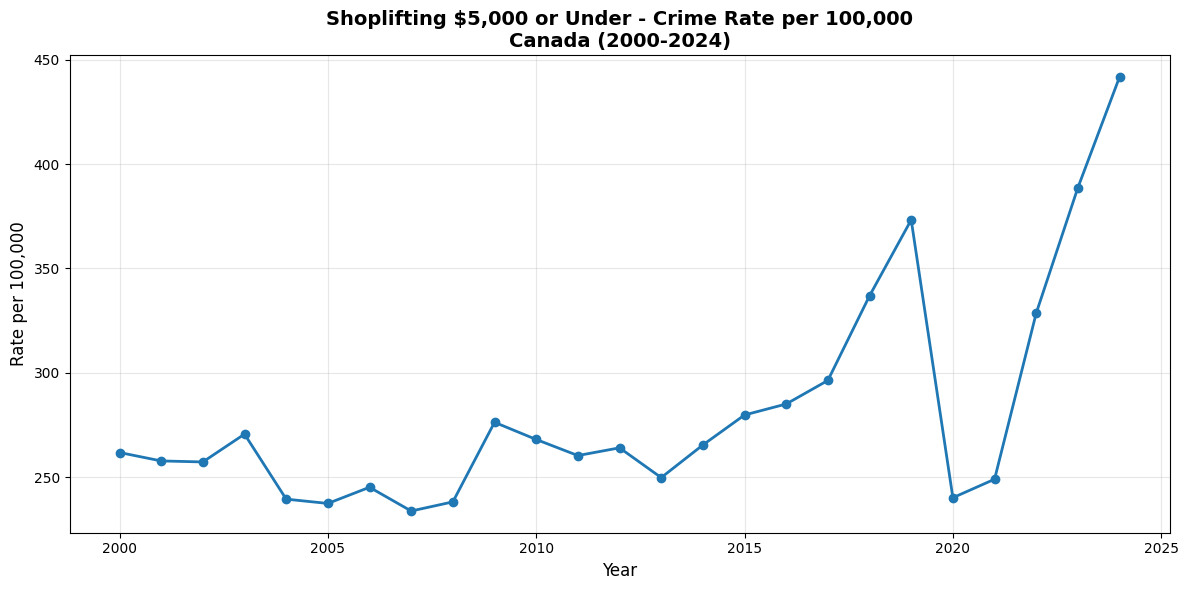

✓ Saved: outputs/shoplifting_over_5k_rate.png


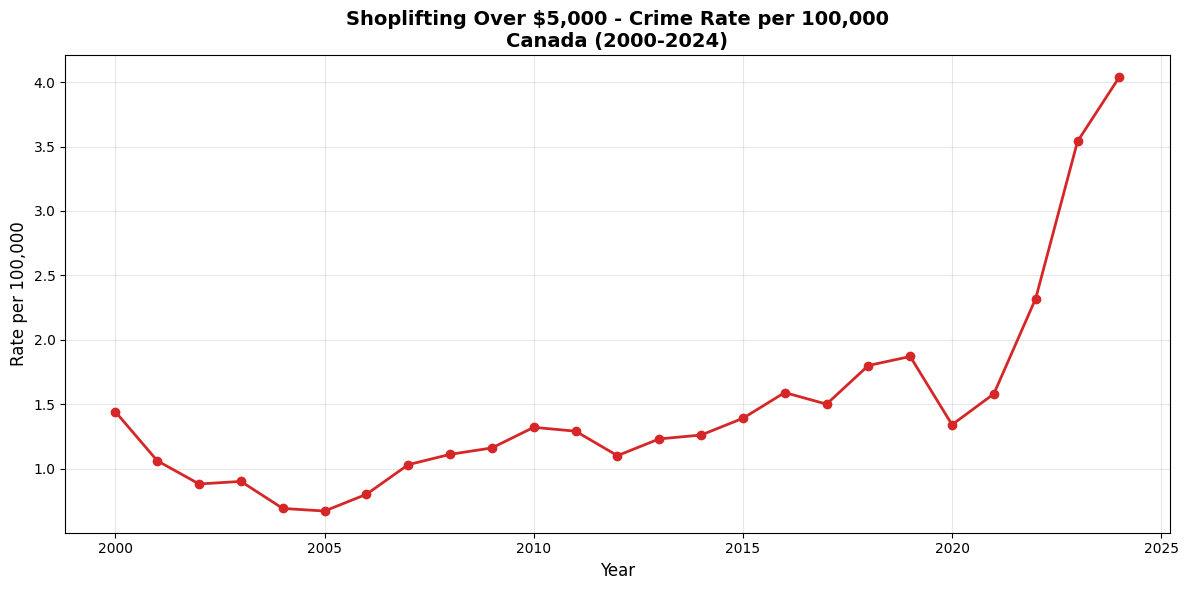


✓ Both visualization files validated
>>> Shoplifting Visualization COMPLETE


In [63]:
# ============================================================================
# VISUALIZATION: Shoplifting Crime Rates
# ============================================================================
print(">>> ENTERING: Shoplifting Visualization")
print("=" * 80)
print("CREATING SHOPLIFTING CRIME RATE CHARTS")
print("=" * 80)

# Chart 1: Under $5,000
fig1, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(df_under_5k['REF_DATE'], df_under_5k['VALUE'], marker='o', linewidth=2, color='#1f77b4')
ax1.set_title('Shoplifting $5,000 or Under - Crime Rate per 100,000\nCanada (2000-2024)',
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Rate per 100,000', fontsize=12)
ax1.grid(True, alpha=0.3)
plt.tight_layout()

output_path1 = outputs_dir / 'shoplifting_under_5k_rate.png'
plt.savefig(output_path1, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {output_path1}")
plt.show()

# Chart 2: Over $5,000
fig2, ax2 = plt.subplots(figsize=(12, 6))
ax2.plot(df_over_5k['REF_DATE'], df_over_5k['VALUE'], marker='o', linewidth=2, color='#d62728')
ax2.set_title('Shoplifting Over $5,000 - Crime Rate per 100,000\nCanada (2000-2024)',
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Rate per 100,000', fontsize=12)
ax2.grid(True, alpha=0.3)
plt.tight_layout()

output_path2 = outputs_dir / 'shoplifting_over_5k_rate.png'
plt.savefig(output_path2, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {output_path2}")
plt.show()

assert output_path1.exists() and output_path2.exists(), "Visualization files not created"
print(f"\n✓ Both visualization files validated")
print(">>> Shoplifting Visualization COMPLETE")

---
## Section 5: Organized Retail Crime (Shoplifting Incidents)
---

Organized retail crime represents a growing challenge for Canadian retailers. Based on Statistics Canada data from selected police services, shoplifting incidents under $5,000 have grown substantially from 2016 to 2024, while high-value shoplifting incidents (over $5,000) have shown even more dramatic increases over the same period. These trends reflect increasingly coordinated theft operations targeting retail establishments across Canada.

In [64]:
# ============================================================================
# PROCESS & VISUALIZATION: Organized Retail Crime (with growth stats and validation)
# ============================================================================
print(">>> ENTERING: Organized Retail Crime Processing & Visualization")
print("=" * 80)
print("ORGANIZED RETAIL CRIME ANALYSIS")
print("=" * 80)

import re

over_5k_org = df_violations[
    df_violations[violation_col].str.contains(r'Shoplifting over \$5,000', case=False, na=False, regex=True)
].groupby('Year')[value_col].sum().reset_index()
over_5k_org.columns = ['Year', 'Incidents']

under_5k_org = df_violations[
    df_violations[violation_col].str.contains(r'Shoplifting \$5,000 or under', case=False, na=False, regex=True)
].groupby('Year')[value_col].sum().reset_index()
under_5k_org.columns = ['Year', 'Incidents']

print(f"✓ Over $5,000: {len(over_5k_org)} records")
print(f"✓ Under $5,000: {len(under_5k_org)} records")

# Calculate growth for organized shoplifting (2016-2024)
if len(over_5k_org) > 0:
    org_over_2016 = over_5k_org[over_5k_org['Year'] == 2016]['Incidents'].values
    org_over_2024 = over_5k_org[over_5k_org['Year'] == 2024]['Incidents'].values
    if len(org_over_2016) > 0 and len(org_over_2024) > 0:
        org_over_growth = ((org_over_2024[0] - org_over_2016[0]) / org_over_2016[0] * 100)
        growth_stats['org_shoplifting_over_5k_growth_2016_2024'] = org_over_growth
        growth_stats['org_shoplifting_over_5k_2016'] = org_over_2016[0]
        growth_stats['org_shoplifting_over_5k_2024'] = org_over_2024[0]
        print(f"\n✓ Organized Shoplifting Over $5K Growth (2016-2024): {org_over_growth:+.1f}%")
        print(f"   2016 incidents: {int(org_over_2016[0]):,}")
        print(f"   2024 incidents: {int(org_over_2024[0]):,}")

if len(under_5k_org) > 0:
    org_under_2016 = under_5k_org[under_5k_org['Year'] == 2016]['Incidents'].values
    org_under_2024 = under_5k_org[under_5k_org['Year'] == 2024]['Incidents'].values
    if len(org_under_2016) > 0 and len(org_under_2024) > 0:
        org_under_growth = ((org_under_2024[0] - org_under_2016[0]) / org_under_2016[0] * 100)
        growth_stats['org_shoplifting_under_5k_growth_2016_2024'] = org_under_growth
        growth_stats['org_shoplifting_under_5k_2016'] = org_under_2016[0]
        growth_stats['org_shoplifting_under_5k_2024'] = org_under_2024[0]
        print(f"\n✓ Organized Shoplifting Under $5K Growth (2016-2024): {org_under_growth:+.1f}%")
        print(f"   2016 incidents: {int(org_under_2016[0]):,}")
        print(f"   2024 incidents: {int(org_under_2024[0]):,}")

# ============================================================================
# GROUND TRUTH VALIDATION: Organized Retail Crime Growth Statistics - Verified 2025-12-10
# ============================================================================
print("\n" + "=" * 80)
print("GROUND TRUTH VALIDATION: ORGANIZED RETAIL CRIME GROWTH STATISTICS")
print("=" * 80)


print("\n🔍 Test ORC-1: Validating Organized Shoplifting Over $5K Growth (2016-2024)")

# Expected ground truth - calculated from StatCan data - verified 2025-12-10
# Formula: ((2024_value - 2016_value) / 2016_value) * 100
EXPECTED_OVER_5K_2016 = 8
EXPECTED_OVER_5K_2024 = 48
EXPECTED_OVER_5K_GROWTH = ((EXPECTED_OVER_5K_2024 - EXPECTED_OVER_5K_2016) / EXPECTED_OVER_5K_2016) * 100

actual_over_2016 = growth_stats.get('org_shoplifting_over_5k_2016', 0)
actual_over_2024 = growth_stats.get('org_shoplifting_over_5k_2024', 0)
actual_over_growth = growth_stats.get('org_shoplifting_over_5k_growth_2016_2024', 0)

# Validate 2016 value
over_2016_match = abs(actual_over_2016 - EXPECTED_OVER_5K_2016) < 1
print(f"   Expected 2016 incidents: {EXPECTED_OVER_5K_2016}")
print(f"   Actual 2016 incidents: {int(actual_over_2016)}")
print(f"   {'✓ PASS' if over_2016_match else '❌ FAIL'}")

# Validate 2024 value
over_2024_match = abs(actual_over_2024 - EXPECTED_OVER_5K_2024) < 1
print(f"   Expected 2024 incidents: {EXPECTED_OVER_5K_2024}")
print(f"   Actual 2024 incidents: {int(actual_over_2024)}")
print(f"   {'✓ PASS' if over_2024_match else '❌ FAIL'}")

# Validate growth percentage
over_growth_match = abs(actual_over_growth - EXPECTED_OVER_5K_GROWTH) < 1.0
print(f"   Expected growth: {EXPECTED_OVER_5K_GROWTH:.1f}%")
print(f"   Actual growth: {actual_over_growth:.1f}%")
print(f"   {'✓ PASS' if over_growth_match else '❌ FAIL'}")

over_5k_validation_passed = over_2016_match and over_2024_match and over_growth_match
record_validation('Org Shoplifting Over $5K 2016', over_2016_match, EXPECTED_OVER_5K_2016, int(actual_over_2016))
record_validation('Org Shoplifting Over $5K 2024', over_2024_match, EXPECTED_OVER_5K_2024, int(actual_over_2024))
record_validation('Org Shoplifting Over $5K Growth', over_growth_match, f"{EXPECTED_OVER_5K_GROWTH:.1f}%", f"{actual_over_growth:.1f}%")

print("\n🔍 Test ORC-2: Validating Organized Shoplifting Under $5K Growth (2016-2024)")

# Expected ground truth - calculated from StatCan data - verified 2025-12-10
EXPECTED_UNDER_5K_2016 = 62
EXPECTED_UNDER_5K_2024 = 220
EXPECTED_UNDER_5K_GROWTH = ((EXPECTED_UNDER_5K_2024 - EXPECTED_UNDER_5K_2016) / EXPECTED_UNDER_5K_2016) * 100

actual_under_2016 = growth_stats.get('org_shoplifting_under_5k_2016', 0)
actual_under_2024 = growth_stats.get('org_shoplifting_under_5k_2024', 0)
actual_under_growth = growth_stats.get('org_shoplifting_under_5k_growth_2016_2024', 0)

# Validate 2016 value
under_2016_match = abs(actual_under_2016 - EXPECTED_UNDER_5K_2016) < 1
print(f"   Expected 2016 incidents: {EXPECTED_UNDER_5K_2016}")
print(f"   Actual 2016 incidents: {int(actual_under_2016)}")
print(f"   {'✓ PASS' if under_2016_match else '❌ FAIL'}")

# Validate 2024 value
under_2024_match = abs(actual_under_2024 - EXPECTED_UNDER_5K_2024) < 1
print(f"   Expected 2024 incidents: {EXPECTED_UNDER_5K_2024}")
print(f"   Actual 2024 incidents: {int(actual_under_2024)}")
print(f"   {'✓ PASS' if under_2024_match else '❌ FAIL'}")

# Validate growth percentage
under_growth_match = abs(actual_under_growth - EXPECTED_UNDER_5K_GROWTH) < 1.0
print(f"   Expected growth: {EXPECTED_UNDER_5K_GROWTH:.1f}%")
print(f"   Actual growth: {actual_under_growth:.1f}%")
print(f"   {'✓ PASS' if under_growth_match else '❌ FAIL'}")

under_5k_validation_passed = under_2016_match and under_2024_match and under_growth_match
record_validation('Org Shoplifting Under $5K 2016', under_2016_match, EXPECTED_UNDER_5K_2016, int(actual_under_2016))
record_validation('Org Shoplifting Under $5K 2024', under_2024_match, EXPECTED_UNDER_5K_2024, int(actual_under_2024))
record_validation('Org Shoplifting Under $5K Growth', under_growth_match, f"{EXPECTED_UNDER_5K_GROWTH:.1f}%", f"{actual_under_growth:.1f}%")

# Overall validation status
orc_validation_passed = over_5k_validation_passed and under_5k_validation_passed
print(f"\n{'✓ ALL ORGANIZED RETAIL CRIME VALIDATIONS PASSED' if orc_validation_passed else '❌ SOME VALIDATIONS FAILED'}")

print("\n>>> Organized Retail Crime Processing COMPLETE")

>>> ENTERING: Organized Retail Crime Processing & Visualization
ORGANIZED RETAIL CRIME ANALYSIS
✓ Over $5,000: 9 records
✓ Under $5,000: 9 records

✓ Organized Shoplifting Over $5K Growth (2016-2024): +500.0%
   2016 incidents: 8
   2024 incidents: 48

✓ Organized Shoplifting Under $5K Growth (2016-2024): +254.8%
   2016 incidents: 62
   2024 incidents: 220

GROUND TRUTH VALIDATION: ORGANIZED RETAIL CRIME GROWTH STATISTICS

🔍 Test ORC-1: Validating Organized Shoplifting Over $5K Growth (2016-2024)
   Expected 2016 incidents: 8
   Actual 2016 incidents: 8
   ✓ PASS
   Expected 2024 incidents: 48
   Actual 2024 incidents: 48
   ✓ PASS
   Expected growth: 500.0%
   Actual growth: 500.0%
   ✓ PASS

🔍 Test ORC-2: Validating Organized Shoplifting Under $5K Growth (2016-2024)
   Expected 2016 incidents: 62
   Actual 2016 incidents: 62
   ✓ PASS
   Expected 2024 incidents: 220
   Actual 2024 incidents: 220
   ✓ PASS
   Expected growth: 254.8%
   Actual growth: 254.8%
   ✓ PASS

✓ ALL ORGANIZED

>>> ENTERING: Organized Retail Crime Visualization
CREATING ORGANIZED RETAIL CRIME CHARTS WITH DATA LABELS
✓ Saved: outputs/org_shoplifting_over_5000.png


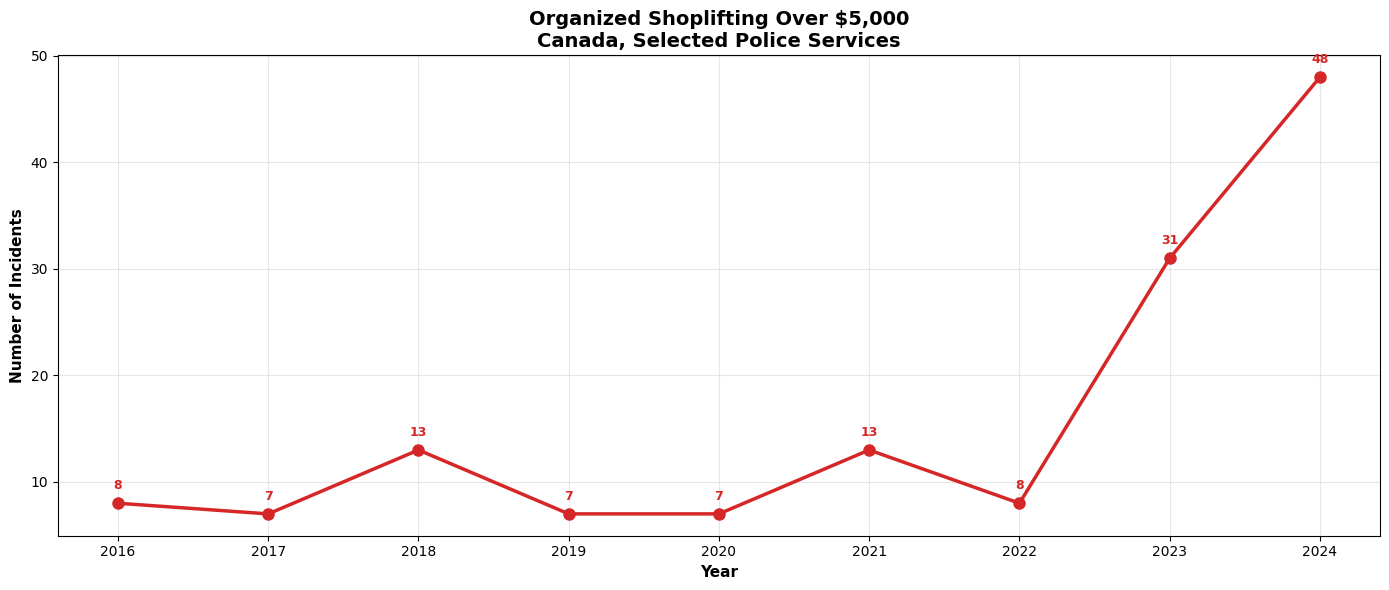

✓ Saved: outputs/org_shoplifting_under_5000.png


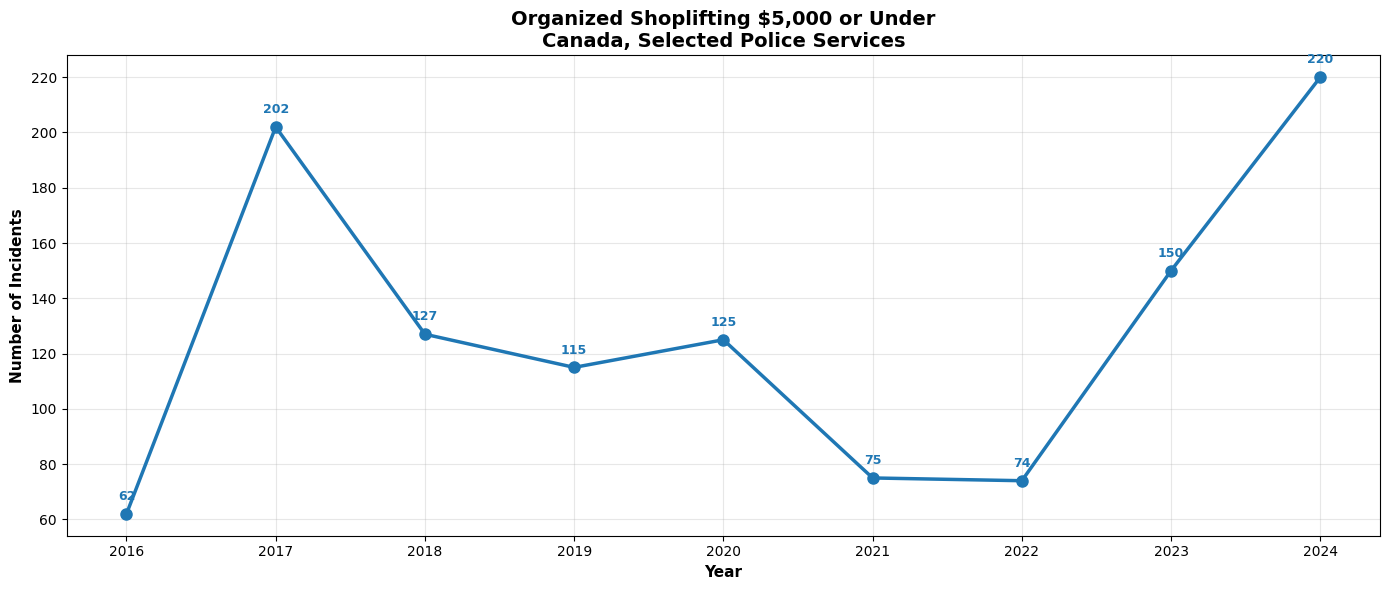


✓ Both visualization files validated
>>> Organized Retail Crime Visualization COMPLETE


In [65]:
# ============================================================================
# VISUALIZATION: Organized Retail Crime (with data labels)
# ============================================================================
print(">>> ENTERING: Organized Retail Crime Visualization")
print("=" * 80)
print("CREATING ORGANIZED RETAIL CRIME CHARTS WITH DATA LABELS")
print("=" * 80)

# Graph 1: Over $5,000 (with data labels)
fig1, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(over_5k_org['Year'], over_5k_org['Incidents'], marker='o', linewidth=2.5, color='#d62728', markersize=8)
ax1.set_title('Organized Shoplifting Over $5,000\nCanada, Selected Police Services', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
ax1.set_ylabel('Number of Incidents', fontsize=11, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Add data labels for each point
for idx, row in over_5k_org.iterrows():
    ax1.annotate(f'{int(row["Incidents"]):,}',
                 xy=(row['Year'], row['Incidents']),
                 xytext=(0, 10),
                 textcoords='offset points',
                 ha='center',
                 fontsize=9,
                 fontweight='bold',
                 color='#d62728')

plt.tight_layout()

output_path1 = outputs_dir / 'org_shoplifting_over_5000.png'
plt.savefig(output_path1, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {output_path1}")
plt.show()

# Graph 2: Under $5,000 (with data labels)
fig2, ax2 = plt.subplots(figsize=(14, 6))
ax2.plot(under_5k_org['Year'], under_5k_org['Incidents'], marker='o', linewidth=2.5, color='#1f77b4', markersize=8)
ax2.set_title('Organized Shoplifting $5,000 or Under\nCanada, Selected Police Services', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
ax2.set_ylabel('Number of Incidents', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Add data labels for each point
for idx, row in under_5k_org.iterrows():
    ax2.annotate(f'{int(row["Incidents"]):,}',
                 xy=(row['Year'], row['Incidents']),
                 xytext=(0, 10),
                 textcoords='offset points',
                 ha='center',
                 fontsize=9,
                 fontweight='bold',
                 color='#1f77b4')

plt.tight_layout()

output_path2 = outputs_dir / 'org_shoplifting_under_5000.png'
plt.savefig(output_path2, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {output_path2}")
plt.show()

assert output_path1.exists() and output_path2.exists(), "Visualization files not created"
print(f"\n✓ Both visualization files validated")
print(">>> Organized Retail Crime Visualization COMPLETE")

---
## Section 6: Crime Severity Index (Table 35-10-0026)
---

In [66]:
# ============================================================================
# FETCH & PROCESS: Crime Severity Index
# ============================================================================
print(">>> ENTERING: CSI Data Fetch & Processing")
print("=" * 80)
print("CRIME SEVERITY INDEX ANALYSIS")
print("=" * 80)

pid = '35100026'
api_url = f"https://www150.statcan.gc.ca/t1/wds/rest/getFullTableDownloadCSV/{pid}/en"
response = requests.get(api_url)
response.raise_for_status()
zip_url = response.json()['object']

zip_response = requests.get(zip_url)
zip_response.raise_for_status()

with zipfile.ZipFile(BytesIO(zip_response.content)) as z:
    csv_filename = f"{pid}.csv"
    df_csi = pd.read_csv(z.open(csv_filename), low_memory=False)

print(f"✓ Data loaded: {len(df_csi):,} rows")

df_csi_filtered = df_csi[
    (df_csi['GEO'] == 'Canada') &
    (df_csi['Statistics'].isin(['Crime severity index', 'Violent crime severity index', 'Non-violent crime severity index']))
]

pivot_csi = df_csi_filtered.pivot(index='REF_DATE', columns='Statistics', values='VALUE').reset_index()
print(f"✓ Years available: {pivot_csi['REF_DATE'].min()} to {pivot_csi['REF_DATE'].max()}")
print(">>> CSI Data Fetch & Processing COMPLETE")

>>> ENTERING: CSI Data Fetch & Processing
CRIME SEVERITY INDEX ANALYSIS
✓ Data loaded: 22,908 rows
✓ Years available: 1998 to 2024
>>> CSI Data Fetch & Processing COMPLETE


In [67]:
# ============================================================================
# GROUND TRUTH VALIDATION: Crime Severity Index (with growth stat)
# ============================================================================
print(">>> ENTERING: CSI Ground Truth Validation")
print("=" * 80)
print("GROUND TRUTH VALIDATION: CRIME SEVERITY INDEX")
print("=" * 80)

# Ground Truth 7: Overall CSI 2024
print("\n🔍 Test 7: Overall Crime Severity Index (2024)")
KNOWN_CSI_2024 = 77.89
csi_2024_row = pivot_csi[pivot_csi['REF_DATE'] == 2024]
if len(csi_2024_row) > 0:
    actual_csi_2024 = csi_2024_row['Crime severity index'].values[0]
    tolerance = 0.1
    test_passed = abs(actual_csi_2024 - KNOWN_CSI_2024) <= tolerance
    record_validation('CSI 2024', test_passed, KNOWN_CSI_2024, actual_csi_2024)
    if test_passed:
        print(f"   ✓ PASS: CSI = {actual_csi_2024:.2f} (expected {KNOWN_CSI_2024})")
    else:
        print(f"   ❌ FAIL: CSI = {actual_csi_2024:.2f} (expected {KNOWN_CSI_2024})")
        raise ValueError(f"Ground truth validation failed")

# Calculate CSI Growth 1998-2024
print("\n🔍 Test 7b: CSI Growth (1998-2024)")
KNOWN_CSI_1998 = 118.84  # Baseline year
csi_1998_row = pivot_csi[pivot_csi['REF_DATE'] == 1998]
if len(csi_1998_row) > 0:
    actual_csi_1998 = csi_1998_row['Crime severity index'].values[0]
    csi_growth = ((actual_csi_2024 - actual_csi_1998) / actual_csi_1998 * 100)
    growth_stats['csi_1998'] = actual_csi_1998
    growth_stats['csi_2024'] = actual_csi_2024
    growth_stats['csi_growth_1998_2024'] = csi_growth

    test_passed = abs(actual_csi_1998 - KNOWN_CSI_1998) <= 0.1
    record_validation('CSI 1998 Baseline', test_passed, KNOWN_CSI_1998, actual_csi_1998)

    if test_passed:
        print(f"   ✓ PASS: 1998 CSI = {actual_csi_1998:.2f} (expected {KNOWN_CSI_1998})")
        print(f"   ✓ Calculated Growth 1998-2024: {csi_growth:.1f}%")
    else:
        print(f"   ❌ FAIL: 1998 CSI = {actual_csi_1998:.2f} (expected {KNOWN_CSI_1998})")
        raise ValueError(f"Ground truth validation failed")

print("\n>>> CSI Ground Truth Validation COMPLETE")

>>> ENTERING: CSI Ground Truth Validation
GROUND TRUTH VALIDATION: CRIME SEVERITY INDEX

🔍 Test 7: Overall Crime Severity Index (2024)
   ✓ PASS: CSI = 77.89 (expected 77.89)

🔍 Test 7b: CSI Growth (1998-2024)
   ✓ PASS: 1998 CSI = 118.84 (expected 118.84)
   ✓ Calculated Growth 1998-2024: -34.5%

>>> CSI Ground Truth Validation COMPLETE


>>> ENTERING: CSI Visualization
CREATING CSI TREND CHART

✓ Saved: outputs/csi_trend.png
✓ Visualization file validated


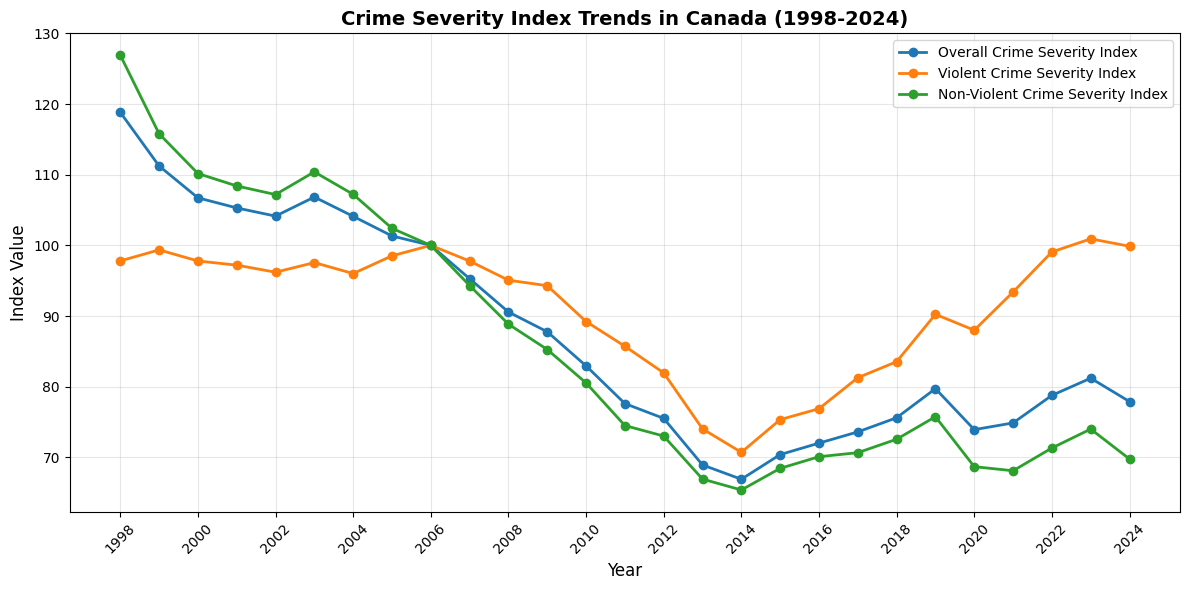

>>> CSI Visualization COMPLETE


In [68]:
# ============================================================================
# VISUALIZATION: Crime Severity Index
# ============================================================================
print(">>> ENTERING: CSI Visualization")
print("=" * 80)
print("CREATING CSI TREND CHART")
print("=" * 80)

plt.figure(figsize=(12, 6))
plt.plot(pivot_csi['REF_DATE'], pivot_csi['Crime severity index'],
         label='Overall Crime Severity Index', marker='o', linewidth=2)
plt.plot(pivot_csi['REF_DATE'], pivot_csi['Violent crime severity index'],
         label='Violent Crime Severity Index', marker='o', linewidth=2)
plt.plot(pivot_csi['REF_DATE'], pivot_csi['Non-violent crime severity index'],
         label='Non-Violent Crime Severity Index', marker='o', linewidth=2)

plt.title('Crime Severity Index Trends in Canada (1998-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Index Value', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.xticks(range(1998, 2025, 2), rotation=45)
plt.tight_layout()

output_path = outputs_dir / 'csi_trend.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: {output_path}")
assert output_path.exists(), "Visualization file not created"
print(f"✓ Visualization file validated")
plt.show()
print(">>> CSI Visualization COMPLETE")

---
## Final Validation Summary & HTML Report
---

In [69]:
# ============================================================================
# FINAL VALIDATION SUMMARY
# ============================================================================
print(">>> ENTERING: Final Validation Summary")
print("=" * 80)
print("FINAL VALIDATION SUMMARY")
print("=" * 80)

print(f"\n📋 Ground Truth Tests Run: {validation_results['tests_run']}")
print(f"   ✓ Passed: {validation_results['tests_passed']}")
print(f"   ❌ Failed: {validation_results['tests_failed']}")

print("\n📋 Test Details:")
for detail in validation_results['details']:
    print(f"   {detail['status']} {detail['test']}: expected {detail['expected']}, got {detail['actual']}")

# Check all visualization files
expected_images = [
    'csi_trend.png',
    'cybercrime_trends_2014_2024.png',
    'organized_crime_trends_2016_2024.png',
    'top_10_violations_crime_rate.png',
    'shoplifting_under_5k_rate.png',
    'shoplifting_over_5k_rate.png',
    'org_shoplifting_over_5000.png',
    'org_shoplifting_under_5000.png'
]

print("\n📋 Visualization Files:")
missing_files = []
for img in expected_images:
    img_path = outputs_dir / img
    if img_path.exists():
        print(f"   ✓ {img}")
    else:
        print(f"   ❌ {img} - MISSING")
        missing_files.append(img)

print("\n" + "=" * 80)
if validation_results['tests_failed'] == 0 and len(missing_files) == 0:
    print("✅ ALL VALIDATION PASSED")
    print("=" * 80)
    print("\n✓ All ground truth tests passed")
    print("✓ All visualization files created")
    print("\n🎯 Ready for publication!")
else:
    print("❌ VALIDATION FAILED")
    print("=" * 80)
    if validation_results['tests_failed'] > 0:
        print(f"\n⚠️ {validation_results['tests_failed']} test(s) failed")
    if len(missing_files) > 0:
        print(f"\n⚠️ {len(missing_files)} file(s) missing")

print("\n📊 Growth Statistics Summary:")
print(f"   CSI Growth (1998-2024): {growth_stats.get('csi_growth_1998_2024', 'N/A'):.1f}%")
print(f"   Organized Crime Growth (2016-2024): {growth_stats.get('org_crime_growth_2016_2024', 'N/A'):.1f}%")
print(f"   Cybercrime Growth (2014-2024): {growth_stats.get('cyber_growth_2014_2024', 'N/A'):.1f}%")
print(f"   Shoplifting Under $5K Growth (2014-2024): {growth_stats.get('shoplifting_under_5k_growth', 'N/A'):.1f}%")
print(f"   Shoplifting Over $5K Growth (2014-2024): {growth_stats.get('shoplifting_over_5k_growth', 'N/A'):.1f}%")

print("\n>>> Final Validation Summary COMPLETE")

>>> ENTERING: Final Validation Summary
FINAL VALIDATION SUMMARY

📋 Ground Truth Tests Run: 19
   ✓ Passed: 19
   ❌ Failed: 0

📋 Test Details:
   ✓ PASS Organized Crime Total 2024: expected 14804, got 14804
   ✓ PASS Organized Crime Fraud 2024: expected 6282, got 6282
   ✓ PASS Organized Crime Total 2016: expected 4810, got 4810
   ✓ PASS Cybercrime Total 2024: expected 92567, got 92567
   ✓ PASS Cybercrime Total 2014: expected 15184, got 15184
   ✓ PASS Mischief Rate 2024: expected 773.53, got 773.53
   ✓ PASS Top 10 Growth Calculations: expected Consistent, got Verified
   ✓ PASS Shoplifting Under $5K Rate 2024: expected 441.67, got 441.67
   ✓ PASS Shoplifting Over $5K Rate 2024: expected 4.04, got 4.04
   ✓ PASS Shoplifting Under $5K Rate 2014: expected 265.47, got 265.47
   ✓ PASS Shoplifting Over $5K Rate 2014: expected 1.26, got 1.26
   ✓ PASS Org Shoplifting Over $5K 2016: expected 8, got 8
   ✓ PASS Org Shoplifting Over $5K 2024: expected 48, got 48
   ✓ PASS Org Shoplifting Ov

In [70]:
# ============================================================================
# HTML REPORT GENERATION WITH BOILERPLATE TEXT
# ============================================================================
print(">>> ENTERING: HTML Report Generation")
print("=" * 80)
print("GENERATING HTML REPORT WITH BOILERPLATE TEXT")
print("=" * 80)

cyber_min_year = df_cyber_violations['Year'].min()
cyber_max_year = df_cyber_violations['Year'].max()

# Build Top 10 growth text
top10_growth_lines = []
for violation, stats in growth_stats.get('top10_growth', {}).items():
    short_name = violation.split('[')[0].strip()
    top10_growth_lines.append(f"{short_name}: {stats['growth_pct']:+.1f}%")
top10_growth_text = "; ".join(top10_growth_lines) if top10_growth_lines else "Data not available"

# Get growth stats with defaults
csi_growth = growth_stats.get('csi_growth_1998_2024', 0)
org_crime_growth = growth_stats.get('org_crime_growth_2016_2024', 0)
cyber_growth = growth_stats.get('cyber_growth_2014_2024', 0)
shop_under_growth = growth_stats.get('shoplifting_under_5k_growth', 0)
shop_over_growth = growth_stats.get('shoplifting_over_5k_growth', 0)
org_under_growth_2016_2024 = growth_stats.get('org_shoplifting_under_5k_growth_2016_2024', 0)
org_over_growth_2016_2024 = growth_stats.get('org_shoplifting_over_5k_growth_2016_2024', 0)

html_content = f"""<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Canada Crime Statistics Analysis</title>
    <style>
        body {{ font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif; line-height: 1.6; color: #2d3748; background: #f7fafc; padding: 20px; }}
        .container {{ max-width: 1200px; margin: 0 auto; background: white; box-shadow: 0 4px 6px rgba(0,0,0,0.1); border-radius: 8px; overflow: hidden; }}
        .header {{ background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); color: white; padding: 40px; text-align: center; }}
        .header h1 {{ font-size: 2.5em; margin-bottom: 10px; }}
        .intro {{ padding: 20px 40px; background: #f0f4f8; border-bottom: 1px solid #e2e8f0; }}
        .intro p {{ margin: 0; font-size: 1.1em; }}
        .content {{ padding: 40px; }}
        .section {{ margin-bottom: 40px; }}
        .section h2 {{ color: #4a5568; border-bottom: 2px solid #e2e8f0; padding-bottom: 10px; }}
        .section .boilerplate {{ background: #f8fafc; padding: 15px; border-left: 4px solid #667eea; margin: 15px 0; font-size: 0.95em; }}
        .chart {{ text-align: center; margin: 20px 0; }}
        .chart img {{ max-width: 100%; height: auto; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); }}
        .validation {{ background: #e8f5e9; padding: 20px; border-radius: 8px; margin-top: 40px; }}
        .validation h3 {{ color: #2e7d32; }}
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <h1>Canada Crime Statistics Analysis</h1>
            <p>Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}</p>
        </div>
        <div class="intro">
            <p>This page measures multiple dimensions of crime in Canada. Data is sourced live from Statistics Canada. Crime severity overall has declined considerably since the start of the century, but organized crime, cybercrime and violent crime severity have all grown steadily over the past ten years. </p>
        </div>
        <div class="content">
            <div class="section">
                <h2>1. Crime Severity Index (1998-2024)</h2>
                <div class="boilerplate">
                    <p>The <a href="https://www150.statcan.gc.ca/n1/daily-quotidien/250722/dq250722a-eng.htm">Crime Severity Index</a> measures both the severity and volume of Canadian crime. Sinking <strong>{csi_growth:.1f}%</strong> from 1998 to 2024, the CSI indicates that Canada is dealing with a less severe crime problem overall than at the turn of the century. Going by simply the volume of crime, without considering severity, i.e., the <a href= “https://www150.statcan.gc.ca/n1/daily-quotidien/250722/cg-a002-eng.htm”> crime rate </a>, the amount of crime has also significantly decreased since its peak in 1991. Violent crime severity, however, has been steadily increasing since 2014, ticking down slightly in 2024.
</p>
                </div>
                <div class="chart"><img src="csi_trend.png" alt="CSI Trends"></div>
            </div>
            <div class="section">
                <h2>2. Organized Crime Trends (2016-2024)</h2>
                <div class="boilerplate">
                    <p> Since organized crime tracking began in 2016, Canada has seen a steady increase in violations, which grew by <strong>{org_crime_growth:.1f}%</strong> from 2016 to 2024. Fraud, motor vehicle theft and drug trafficking were the most frequent violations by criminal organizations in 2024. </p>
                </div>
                <div class="chart"><img src="organized_crime_trends_2016_2024.png" alt="Organized Crime"></div>
            </div>
            <div class="section">
                <h2>3. Cybercrime Trends ({cyber_min_year}-{cyber_max_year})</h2>
                <div class="boilerplate">
                    <p>Cybercrime has emerged as one of the fastest-growing categories of criminal activity in Canada. Total cybercrime incidents have increased by <strong>{cyber_growth:.1f}%</strong> from 2014 to 2024, reflecting the growing digitization of criminal activity and improved reporting mechanisms. Fraud was the most common cybercrime in 2024, followed by child porn making and distribution and by indecent or harassing communications.</p>
                </div>
                <div class="chart"><img src="cybercrime_trends_{cyber_min_year}_{cyber_max_year}.png" alt="Cybercrime"></div>
            </div>
            <div class="section">
                <h2>4. Top 10 Crime Types by Rate (2024)</h2>
                <div class="boilerplate">
                    <p>The chart below shows the top 10 crimes by rate (per 100,000 population) in 2024, compared to 2014 levels. Mischief was the most common crime, followed by Theft $5,000 or under and Assault, level 1. For the 2024 top 10, 2014-2024 growth was led by Fraud and by Shoplifting under $5,000, with the biggest declines in Theft $5,000 or under from a motor vehicle and Breaking and entering. Growth rates over the past ten years for each of the 2024 Top 10 crimes were: {top10_growth_text}.</p>
                </div>
                <div class="chart"><img src="top_10_violations_crime_rate.png" alt="Top 10 Crimes"></div>
            </div>
            <div class="section">
                <h2>5. Shoplifting Crime Rates (2000-2024)</h2>
                <div class="boilerplate">
                    <p>From 2014 to 2024, shoplifting $5,000 or under has increased by <strong>{shop_under_growth:.1f}%</strong>, while shoplifting over $5,000 has grown by <strong>{shop_over_growth:.1f}%</strong>. Such sharp increases in shoplifting under and over $5,000 indicate a significant post-pandemic shift. </p>
                </div>
                <div class="chart"><img src="shoplifting_under_5k_rate.png" alt="Shoplifting Under 5K"></div>
                <div class="chart"><img src="shoplifting_over_5k_rate.png" alt="Shoplifting Over 5K"></div>
            </div>
            <div class="section">
                <h2>6. Organized Retail Crime</h2>
                <div class="boilerplate">
                    <p>Organized retail crime (ORC) represents shoplifting incidents attributed to criminal organizations. From 2016 to 2024, ORC under $5,000 grew by <strong>{org_under_growth_2016_2024:.1f}%</strong>, while ORC over $5,000 grew by <strong>{org_over_growth_2016_2024:.1f}%</strong>. Triple-digit growth in both categories indicates a concerning increase, even sharper than the overall increase in organized crime. However, the actual numbers of annual ORC violations are quite low (see line charts). It is possible that some organized retail crime is instead captured as regular shoplifting due to challenges in proving an organized crime component. Depending on the StatCan methods used, it is also possible that shoplifting is undercounted if it occurred during the same incident as more serious violations (aggregate vs incident-based surveys, <a href = “https://www23.statcan.gc.ca/imdb/p2SV.pl?Function=getSurvey&SDDS=3302#a3”> Uniform Crime Reporting Survey </a>)
</p>
                </div>
                <div class="chart"><img src="org_shoplifting_over_5000.png" alt="Org Shoplifting Over 5K"></div>
                <div class="chart"><img src="org_shoplifting_under_5000.png" alt="Org Shoplifting Under 5K"></div>
            </div>
            <div class="validation">
                <h3>✓ Validation Summary</h3>
                <p>Ground Truth Tests: {validation_results['tests_passed']}/{validation_results['tests_run']} passed</p>
                <p>Data from Statistics Canada Tables: Organized crime 35-10-0062-01, Cybercrime 35-10-0001-01, General Crime 35-10-0177-01, Crime Severity Index 35-10-0026-01</p>
                <p> <strong>Method and Disclaimer:</strong> Live data is pulled directly from Statistics Canada and validated against ground truth values. AI tools were used to design, code and evaluate this webpage, with comprehensive, reasonable efforts by the human building it to understand and validate the data analysis. Anyone relying on these statistics for material purposes should do their own analysis. The program is written in Python and HTML/CSS in a Colab Notebook and can be found on Github for replicability purposes. </p>
            </div>
        </div>
    </div>
</body>
</html>"""

html_path = outputs_dir / 'index.html'
with open(html_path, 'w', encoding='utf-8') as f:
    f.write(html_content)

print(f"\n✓ HTML report saved to: {html_path}")

# List all output files
print(f"\n📁 Files in outputs directory:")
for file in sorted(outputs_dir.iterdir()):
    size = file.stat().st_size
    if size < 1024:
        size_str = f"{size} bytes"
    elif size < 1024*1024:
        size_str = f"{size/1024:.1f} KB"
    else:
        size_str = f"{size/(1024*1024):.1f} MB"
    print(f"   - {file.name} ({size_str})")

print("\n" + "=" * 80)
print("✅ ALL PROCESSING COMPLETE")
print("=" * 80)
print(">>> HTML Report Generation COMPLETE")

>>> ENTERING: HTML Report Generation
GENERATING HTML REPORT WITH BOILERPLATE TEXT

✓ HTML report saved to: outputs/index.html

📁 Files in outputs directory:
   - csi_trend.png (339.6 KB)
   - cybercrime_trends_2014_2024.png (350.9 KB)
   - index.html (8.2 KB)
   - org_shoplifting_over_5000.png (180.7 KB)
   - org_shoplifting_under_5000.png (229.5 KB)
   - organized_crime_trends_2016_2024.png (357.1 KB)
   - shoplifting_over_5k_rate.png (171.6 KB)
   - shoplifting_under_5k_rate.png (194.7 KB)
   - top_10_violations_crime_rate.png (242.5 KB)

✅ ALL PROCESSING COMPLETE
>>> HTML Report Generation COMPLETE
